In [242]:
import os
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from typing import Annotated, TypedDict,Literal
from dotenv import load_dotenv
from langchain.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph,START,END

In [243]:
load_dotenv()

True

In [244]:
llm=ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
)

In [245]:
class eval_response(BaseModel):
    evaluation: str
    score: int
    feedback:str=Field(description="Detailed text feedback on how to improve the tweet")

In [246]:
class TweetState(TypedDict):
    topic:str
    tweet: str
    score:int
    iteration:int
    feedback:str
eval_model=llm.with_structured_output(eval_response)

In [247]:
graph=StateGraph(TweetState)

In [248]:
def gen_tweet(state:TweetState)->TweetState:
    message=[SystemMessage(content="You are a helpful assistant that generates tweets based on a given topic. The tweet should be concise, engaging, and relevant to the topic provided."),
            HumanMessage(content=f"Generate a tweet about the following topic: {state['topic']}")
    ]
    output=llm.invoke(message).content
    return {"tweet":output,"iteration":0}
def evaluate_tweet(state:TweetState)->TweetState:
    message=[SystemMessage(content="You are a helpful assistant that evaluates tweets. Return ONLY the structured output with evaluation, score, and feedback fields. Do NOT include the score number as text in the evaluation field."),
            HumanMessage(content=f"Evaluate the following tweet and return structured output with: evaluation (brief assessment), score (1-10), and feedback (improvement suggestions). Tweet: {state['tweet']}")
    ]
    output=eval_model.invoke(message)
    return {"score":output.score,"feedback":output.feedback}
def opt_fun(state:TweetState)->TweetState:
    message=[SystemMessage(content="You are a helpful assistant that optimizes tweets based on feedback. Return ONLY the optimized tweet text."),
            HumanMessage(content=f"Optimize the following tweet based on the feedback provided. Tweet: {state['tweet']}. Feedback: {state['feedback']}")
    ]
    output=llm.invoke(message).content
    return {"tweet":output,"iteration":state["iteration"]+1}
def choice_tweet_fun(state:TweetState)->Literal["Optimizar","END"]:
    if state["score"]>8:
        return END
    else:
        return "Optimizar"

In [249]:
graph.add_node("Genrate",gen_tweet)
graph.add_node("Optimizar",opt_fun)
graph.add_node("Evaluator",evaluate_tweet)
graph.add_edge(START,"Genrate")
graph.add_conditional_edges("Evaluator",choice_tweet_fun,{"Optimizar":"Optimizar",END:END})
graph.add_edge("Optimizar","Evaluator")
graph.add_edge("Genrate","Evaluator")

In [250]:
workflow=graph.compile()

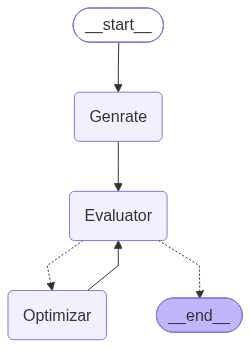

In [251]:
workflow

In [252]:
workflow.invoke({"topic":"AI in military applications"})

{'topic': 'AI in military applications',
 'tweet': '"AI-powered sensors cut response times by 45% in emergency services & 52% in manufacturing. However, 1 in 5 US AI systems are compromised by cyber threats, putting lives at risk. For instance, a major hospital\'s AI system was hacked, exposing patient data of 1 million people. Despite UK\'s AI-driven predictive system saving 75% of wildfires, accountability & transparency concerns remain. A study found AI-driven policing led to a 20% higher arrest rate for Black people. To harness AI\'s potential, we need: transparency, diversity in AI development, & regular cybersecurity audits. Join the call for a robust, 5-step AI framework: 1) Prioritize AI security, 2) Ensure diverse AI development teams, 3) Regularly audit AI systems, 4) Implement transparent AI decision-making, & 5) Develop a national AI ethics board. Let\'s prioritize responsible AI adoption to ensure AI enhances our safety, not puts it at risk. #ResponsibleAI"',
 'score': 9,
